In [1]:
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show

import sys, os, json, time, logging
from datetime import datetime, timedelta
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import rasterio
from rasterio.transform import from_origin
from skimage.transform import resize
from skimage.morphology import binary_dilation, footprint_rectangle
import gcsfs
import ee
import requests

from download_sentinel2 import initialize_earthengine, s2_image_exporter, S2_BANDS, retrieve_time_series_stack

initialize_earthengine()

In [7]:
test_cases = [
    {
        'name': 'California Agriculture (Summer)',
        'lat': 37.5,
        'lon': -120.5,
        'start': '2023-06-01',
        'end': '2023-06-11',
        'collection': 'L2A'
    },
    {
        'name': 'California Agriculture (Summer) - L1C',
        'lat': 37.5,
        'lon': -120.5,
        'start': '2023-06-01',
        'end': '2023-06-11',
        'collection': 'L1C'
    },
    {
        'name': 'California Agriculture (Winter) - 2017 - L2A',
        'lat': 37.5,
        'lon': -120.5,
        'start': '2017-01-01',
        'end': '2017-01-31',
        'collection': 'L2A'
    },
    {
        'name': 'California Agriculture (Winter) - 2017 - L1C',
        'lat': 37.5,
        'lon': -120.5,
        'start': '2017-01-01',
        'end': '2017-01-31',
        'collection': 'L1C'
    },
    {
        'name': 'California Agriculture (cloudy) - 2023 - L1C',
        'lat': 37.5,
        'lon': -120.5,
        'start': '2023-05-01',
        'end': '2023-05-04',
        'collection': 'L1C'
    },
]

out_dir = './test_s2_images'

In [8]:
print("\n" + "="*70)
print("DOWNLOADING TEST IMAGES")
print("="*70 + "\n")

results = []

for i, test in enumerate(test_cases):
    print(f"\n[{i+1}/{len(test_cases)}] {test['name']}")
    print(f"  Location: ({test['lat']}, {test['lon']})")
    print(f"  Date range: {test['start']} to {test['end']}")
    print(f"  Collection: {test['collection']}")
    
    file_name = f"test_{i+1:02d}_{test['collection']}.tif"
    file_path = os.path.join(out_dir, file_name)
    
    # Skip if already downloaded
    if os.path.exists(file_path):
        print(f"  ⊙ Already exists, skipping download")
        results.append({'test': test, 'file_path': file_path, 'success': True})
        continue
    
    result = s2_image_exporter(
        lat=test['lat'],
        lon=test['lon'],
        start_date=test['start'],
        end_date=test['end'],
        file_name=file_name,
        out_dir=out_dir,
        collection=test['collection']
    )
    
    success = os.path.exists(file_path)
    results.append({'test': test, 'file_path': file_path, 'success': success})
    
    if success:
        print(f"  ✓ Success: {file_name}")
    else:
        print(f"  ✗ Failed")

print("\n" + "="*70)
print(f"DOWNLOAD COMPLETE: {sum(r['success'] for r in results)}/{len(results)} successful")
print("="*70)


DOWNLOADING TEST IMAGES


[1/5] California Agriculture (Summer)
  Location: (37.5, -120.5)
  Date range: 2023-06-01 to 2023-06-11
  Collection: L2A
  ⊙ Already exists, skipping download

[2/5] California Agriculture (Summer) - L1C
  Location: (37.5, -120.5)
  Date range: 2023-06-01 to 2023-06-11
  Collection: L1C
  ⊙ Already exists, skipping download

[3/5] California Agriculture (Winter) - 2017 - L2A
  Location: (37.5, -120.5)
  Date range: 2017-01-01 to 2017-01-31
  Collection: L2A
  ⊙ Already exists, skipping download

[4/5] California Agriculture (Winter) - 2017 - L1C
  Location: (37.5, -120.5)
  Date range: 2017-01-01 to 2017-01-31
  Collection: L1C
  ⊙ Already exists, skipping download

[5/5] California Agriculture (cloudy) - 2023 - L1C
  Location: (37.5, -120.5)
  Date range: 2023-05-01 to 2023-05-04
  Collection: L1C
  ✓ Success: test_05_L1C.tif

DOWNLOAD COMPLETE: 5/5 successful


In [9]:
def visualize_s2_image(file_path, test_info):
    """Visualize Sentinel-2 image RGB composite"""
    
    if not os.path.exists(file_path):
        print(f"✗ File not found: {file_path}")
        return
    
    with rasterio.open(file_path) as src:
        # Read RGB bands (B4=Red, B3=Green, B2=Blue)
        rgb = np.dstack([src.read(3), src.read(2), src.read(1)]).astype(float)
        
        # Use the file's nodata value
        nodata = src.nodata if src.nodata is not None else 0
        rgb = np.ma.masked_equal(rgb, nodata)
        
        # Normalize
        rgb_norm = np.clip(rgb / 10000.0, 0, 0.3) / 0.3
        
        # Plot
        plt.figure(figsize=(8, 8))
        plt.imshow(rgb_norm)
        plt.title(f"{test_info['name']} ({test_info['collection']})\n"
                  f"{test_info['start']} to {test_info['end']}")
        plt.axis('off')
        
        # Print stats
        nodata_pct = (rgb == nodata).any(axis=2).sum() / (rgb.shape[0] * rgb.shape[1]) * 100
        print(f"{test_info['name']}: {src.shape[0]}×{src.shape[1]} pixels, "
              f"{nodata_pct:.1f}% masked (nodata={nodata})")
        
        plt.tight_layout()
        plt.show()



VISUALIZING DOWNLOADED IMAGES

----------------------------------------------------------------------
California Agriculture (Summer): 104×103 pixels, 0.0% masked (nodata=0.0)


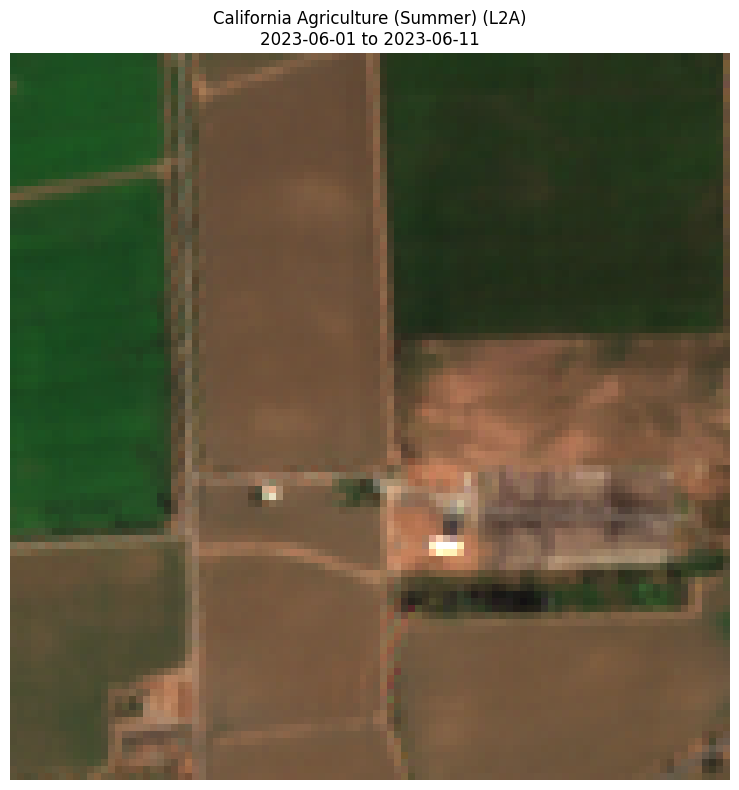


----------------------------------------------------------------------
California Agriculture (Summer) - L1C: 104×103 pixels, 0.0% masked (nodata=0.0)


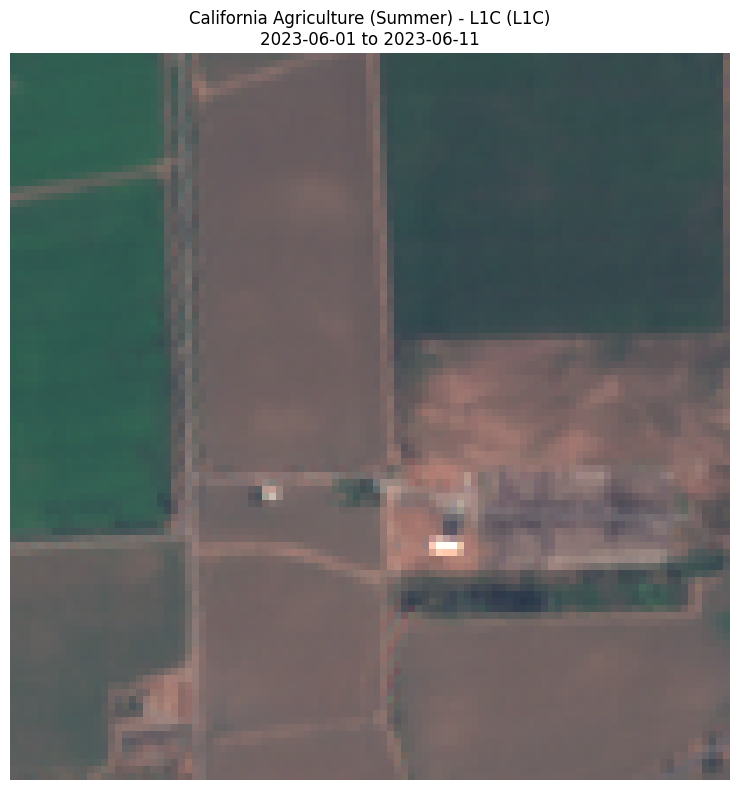


----------------------------------------------------------------------


California Agriculture (Winter) - 2017 - L2A: 104×103 pixels, 0.0% masked (nodata=0.0)


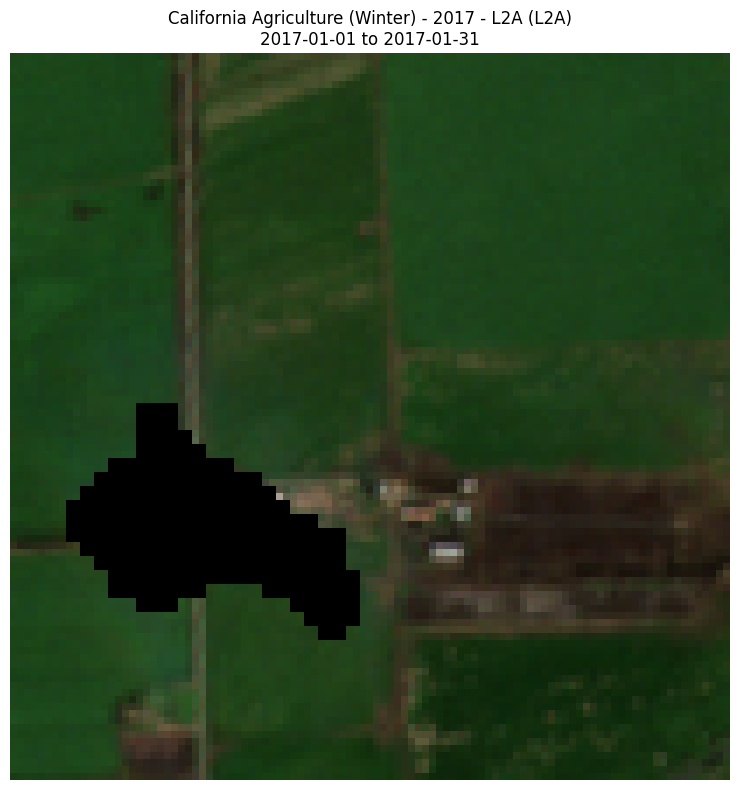


----------------------------------------------------------------------
California Agriculture (Winter) - 2017 - L1C: 104×103 pixels, 0.0% masked (nodata=0.0)


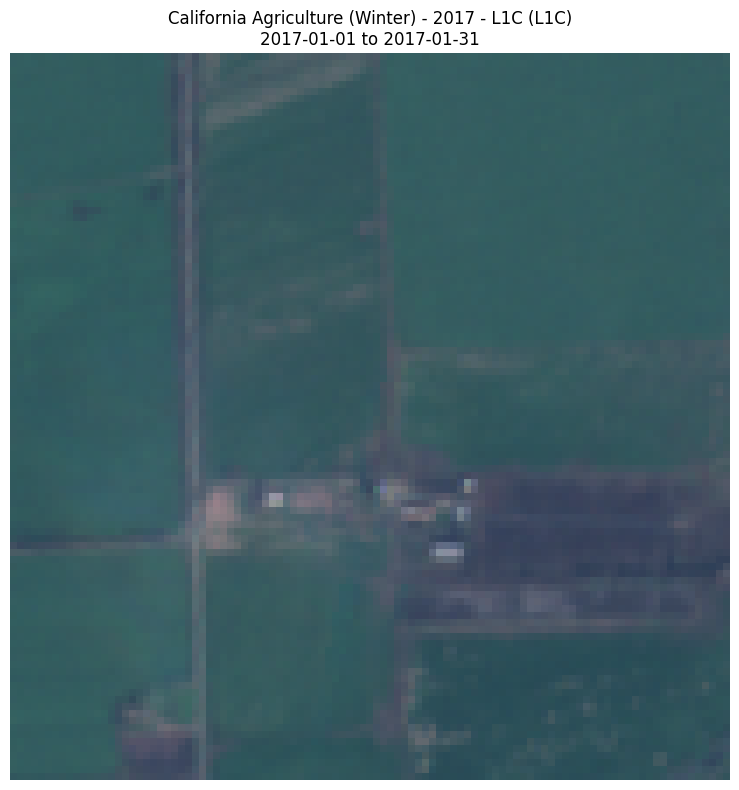


----------------------------------------------------------------------
California Agriculture (cloudy) - 2023 - L1C: 104×103 pixels, --% masked (nodata=0.0)


/var/folders/1f/_ptk0jz93h39qj25crwwtb0w0000gn/T/ipykernel_54918/532595738.py:29: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  f"{nodata_pct:.1f}% masked (nodata={nodata})")


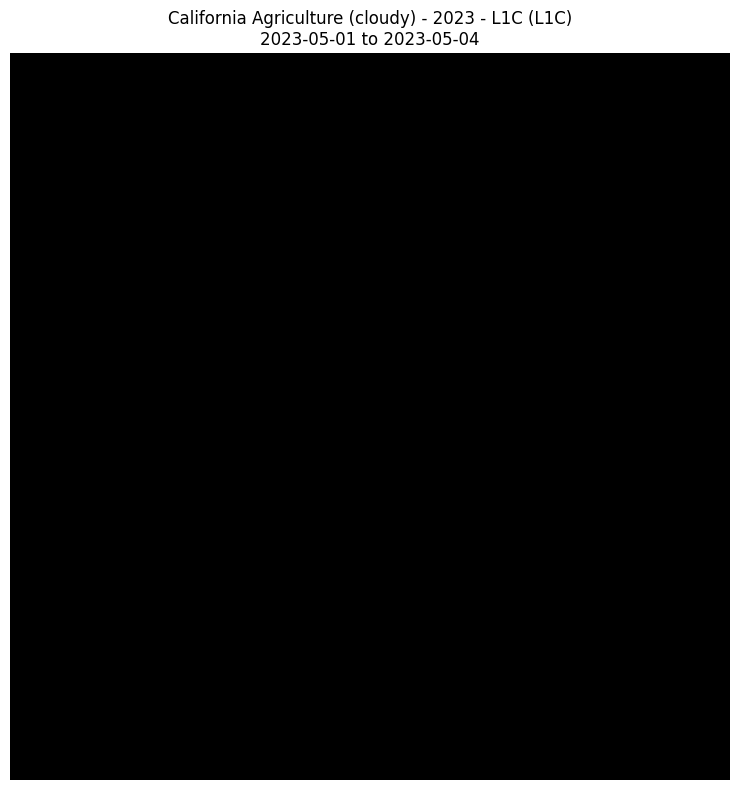

In [10]:
print("\n" + "="*70)
print("VISUALIZING DOWNLOADED IMAGES")
print("="*70)

for result in results:
    if result['success']:
        print("\n" + "-"*70)
        visualize_s2_image(result['file_path'], result['test'])
    else:
        print(f"\n✗ Skipping {result['test']['name']} (download failed)")

In [11]:
def visualize_s2_ndvi(file_path, test_info):
    """Visualize Sentinel-2 NDVI"""
    
    if not os.path.exists(file_path):
        print(f"✗ File not found: {file_path}")
        return
    
    with rasterio.open(file_path) as src:
        # Read NIR (B8=band7) and Red (B4=band3)
        nir = src.read(7).astype(float)
        red = src.read(3).astype(float)
        
        # Use the file's nodata value
        nodata = src.nodata if src.nodata is not None else 0
        
        # Calculate NDVI
        ndvi = (nir - red) / (nir + red + 1e-8)
        
        # Mask nodata
        nodata_mask = (nir == nodata) | (red == nodata)
        ndvi = np.ma.masked_where(nodata_mask, ndvi)
        
        # Plot
        plt.figure(figsize=(8, 8))
        im = plt.imshow(ndvi, cmap='RdYlGn', vmin=-0.2, vmax=0.8)
        plt.colorbar(im, label='NDVI', fraction=0.046, pad=0.04)
        plt.title(f"NDVI: {test_info['name']} ({test_info['collection']})\n"
                  f"{test_info['start']} to {test_info['end']}")
        plt.axis('off')
        
        # Print stats
        valid_ndvi = ndvi.compressed()
        if len(valid_ndvi) > 0:
            print(f"{test_info['name']}: NDVI range [{valid_ndvi.min():.2f}, {valid_ndvi.max():.2f}], "
                  f"mean {valid_ndvi.mean():.2f}")
        
        plt.tight_layout()
        plt.show()


VISUALIZING NDVI

----------------------------------------------------------------------
California Agriculture (Summer): NDVI range [-0.22, 0.90], mean 0.44


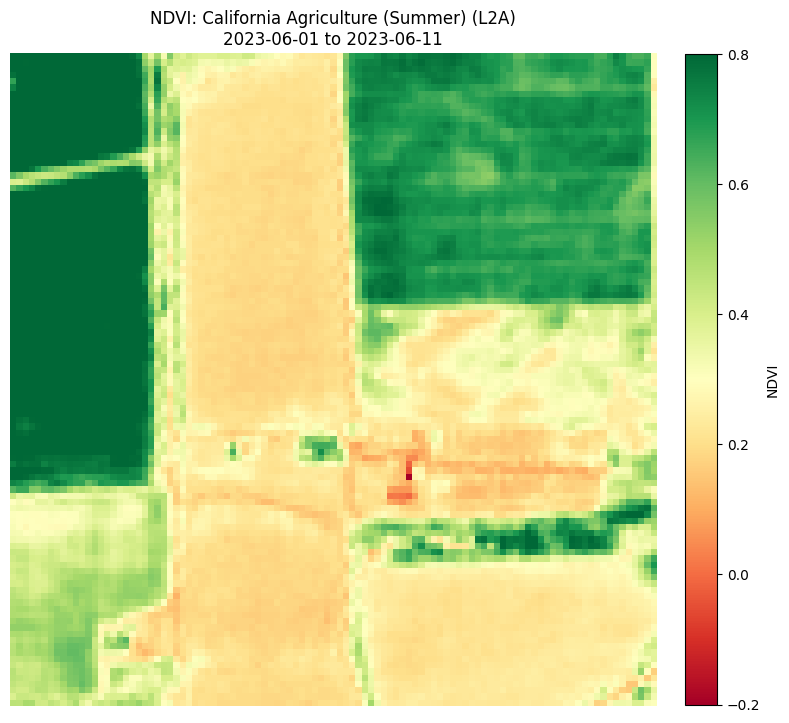


----------------------------------------------------------------------
California Agriculture (Summer) - L1C: NDVI range [-0.12, 0.79], mean 0.37


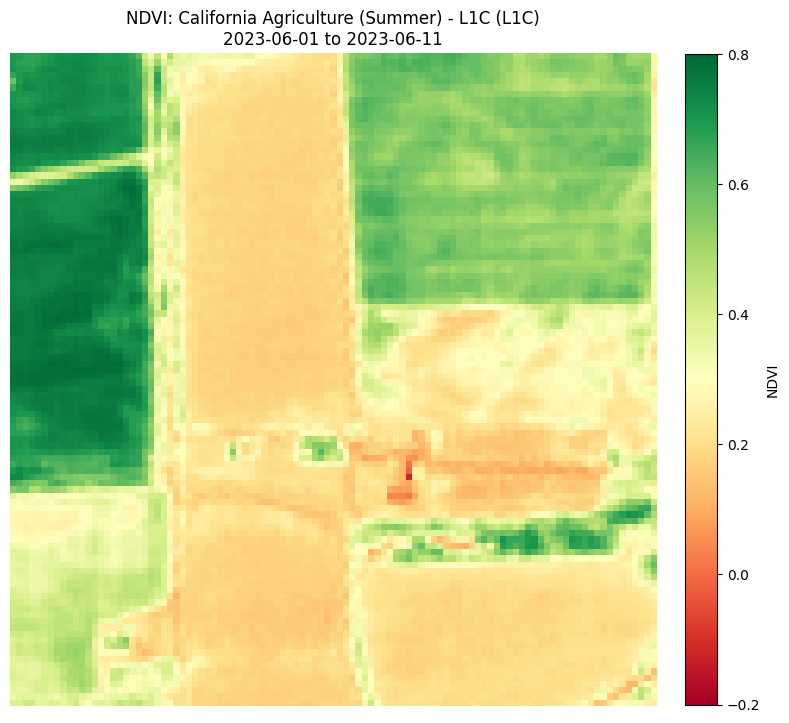


----------------------------------------------------------------------
California Agriculture (Winter) - 2017 - L2A: NDVI range [0.01, 0.95], mean 0.78


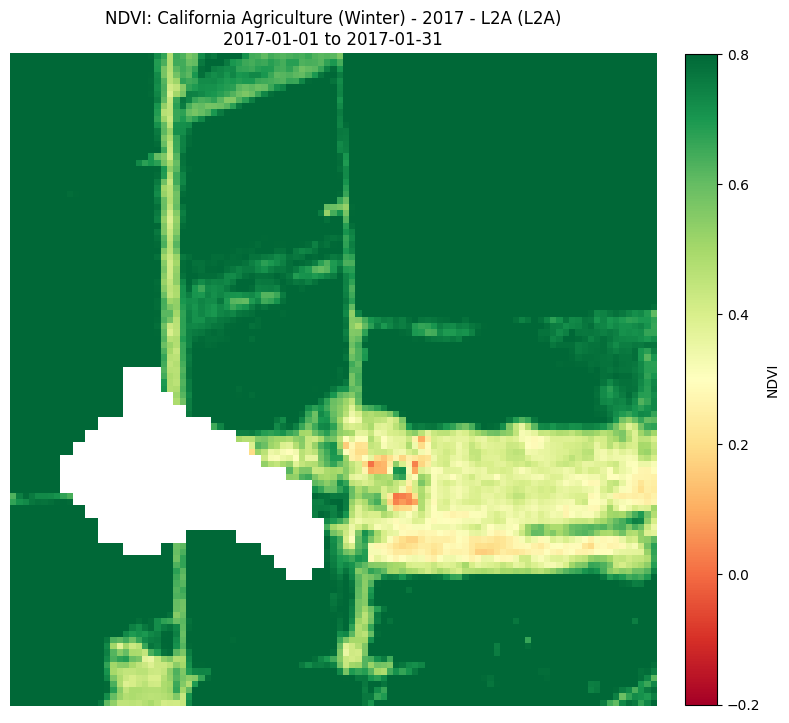


----------------------------------------------------------------------
California Agriculture (Winter) - 2017 - L1C: NDVI range [0.06, 0.81], mean 0.66


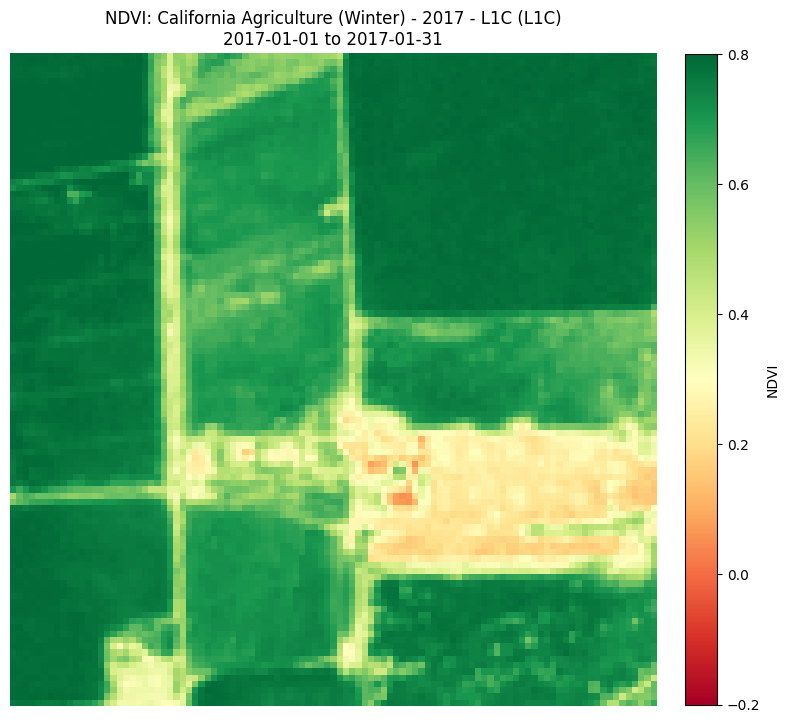


----------------------------------------------------------------------


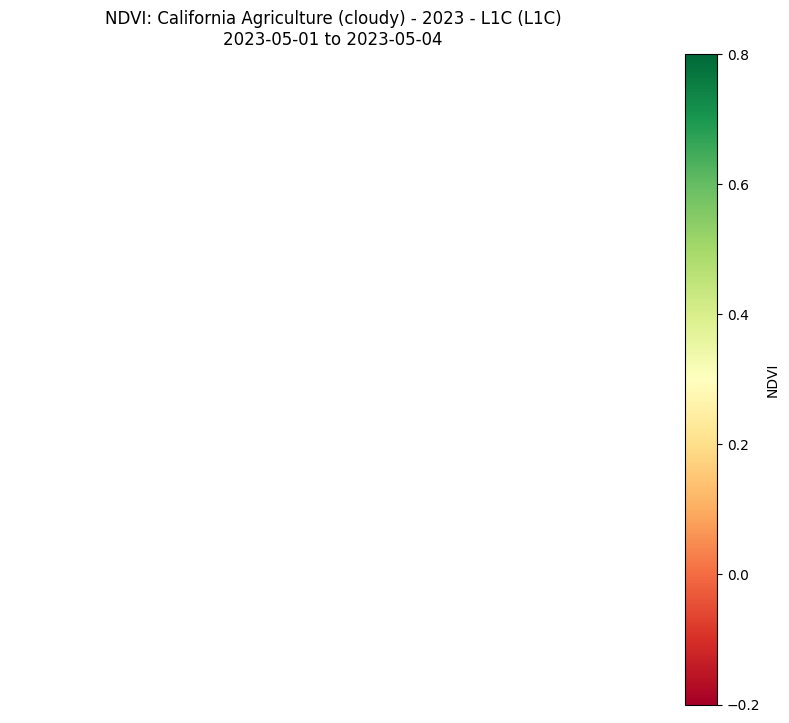

In [12]:
print("\n" + "="*70)
print("VISUALIZING NDVI")
print("="*70)

for result in results:
    if result['success']:
        print("\n" + "-"*70)
        visualize_s2_ndvi(result['file_path'], result['test'])
    else:
        print(f"\n✗ Skipping {result['test']['name']} (download failed)")

In [13]:
import matplotlib.pyplot as plt
import rasterio
from rasterio.plot import show

import sys, os, json, time, logging
from datetime import datetime, timedelta
from concurrent.futures import ThreadPoolExecutor, as_completed

import numpy as np
import pandas as pd
import rasterio
from rasterio.transform import from_origin
from skimage.transform import resize
from skimage.morphology import binary_dilation, footprint_rectangle
import gcsfs
import ee
import requests

from download_sentinel2 import initialize_earthengine, s2_image_exporter, retrieve_time_series_stack

initialize_earthengine()

In [14]:
# Test output directory
TEST_OUT_DIR = './test_timeseries_output_L1C'
os.makedirs(TEST_OUT_DIR, exist_ok=True)

print("="*70)
print("TEST 1: retrieve_time_series_stack()")
print("="*70)

# Test with a known good location
test_site_id = "test_site_001"
test_lat = 37.5
test_lon = -120.5
test_date = datetime(2023, 6, 15)

print(f"\nDownloading stack for:")
print(f"  Site ID: {test_site_id}")
print(f"  Location: ({test_lat}, {test_lon})")
print(f"  Date: {test_date}")
print(f"  Output: {TEST_OUT_DIR}\n")

try:
    retrieve_time_series_stack(
        site_id=test_site_id,
        lat=test_lat,
        lon=test_lon,
        date=test_date,
        collection="L1C",
        out_dir=TEST_OUT_DIR,
        start_month=1,
        num_windows=12,  # Use fewer windows for faster testing
        timestep=10,
        window_buffer=1
    )
    print("\n✓ retrieve_time_series_stack() completed successfully\n")
except Exception as e:
    print(f"\n✗ retrieve_time_series_stack() failed: {e}\n")
    import traceback
    traceback.print_exc()
    sys.exit(1)

TEST 1: retrieve_time_series_stack()

  Site ID: test_site_001
  Location: (37.5, -120.5)
  Date: 2023-06-15 00:00:00
  Output: ./test_timeseries_output_L1C




✓ retrieve_time_series_stack() completed successfully



In [15]:
import numpy as np
import matplotlib.pyplot as plt
import rasterio
import json

def visualize_timeseries_stack(stack_file, metadata_file):
    """
    Load and visualize a stacked time series.
    
    Args:
        stack_file: Path to {site_id}_stack.tif
        metadata_file: Path to {site_id}_metadata.json
    """
    
    # Load metadata
    with open(metadata_file, 'r') as f:
        metadata = json.load(f)
    
    print(f"Site: {metadata['site_id']}")
    print(f"Location: ({metadata['lat']}, {metadata['lon']})")
    print(f"Shape: {metadata['shape']}")
    print(f"Bands: {metadata['bands']}")
    
    # Load stacked image
    with rasterio.open(stack_file) as src:
        stacked_flat = src.read()  # Shape: (num_windows*num_bands, H, W)
        nodata = src.nodata if src.nodata is not None else 0
    
    # Unstack: (num_windows*num_bands, H, W) -> (num_windows, num_bands, H, W)
    T, B, H, W = metadata['shape']
    stacked = stacked_flat.reshape(B, T, H, W).transpose(1, 0, 2, 3)
    
    print(f"\nUnstacked shape: {stacked.shape}")
    print(f"Nodata value: {nodata}")
    
    # Get band indices for RGB
    bands = metadata['bands']
    b2_idx = bands.index('B2')  # Blue
    b3_idx = bands.index('B3')  # Green
    b4_idx = bands.index('B4')  # Red
    b8_idx = bands.index('B8')  # NIR
    
    # 1. Show all timesteps in a grid
    print("\nGenerating grid view of all timesteps...")
    
    n_cols = 6
    n_rows = int(np.ceil(T / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows*3))
    axes = axes.flatten() if T > 1 else [axes]
    
    for i in range(T):
        ax = axes[i]
        
        # Get RGB bands for this timestep
        blue = stacked[i, b2_idx, :, :].astype(float)
        green = stacked[i, b3_idx, :, :].astype(float)
        red = stacked[i, b4_idx, :, :].astype(float)
        
        # Create RGB composite
        rgb = np.dstack([red, green, blue])
        rgb_masked = np.ma.masked_equal(rgb, nodata)
        
        # Normalize
        rgb_norm = np.clip(rgb_masked / 10000.0, 0, 0.3) / 0.3
        
        # Plot
        ax.imshow(rgb_norm)
        ax.set_title(f"{metadata['windows'][i]['date_range'][0]}\n"
                    f"{'✓' if metadata['windows'][i]['file_exists'] else '✗ missing'}", 
                    fontsize=8)
        ax.axis('off')
    
    # Hide unused subplots
    for i in range(T, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f"Time Series: {metadata['site_id']}", fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # 2. NDVI time series
    print("\nCalculating NDVI time series...")
    
    ndvi_means = []
    dates = []
    
    for i in range(T):
        nir = stacked[i, b8_idx, :, :].astype(float)
        red = stacked[i, b4_idx, :, :].astype(float)
        
        # Calculate NDVI
        ndvi = (nir - red) / (nir + red + 1e-8)
        ndvi = np.ma.masked_equal(ndvi, nodata)
        
        # Mean NDVI (excluding nodata)
        if ndvi.compressed().size > 0:
            ndvi_means.append(ndvi.compressed().mean())
        else:
            ndvi_means.append(np.nan)
        
        dates.append(metadata['windows'][i]['date_range'][0])
    
    # Plot NDVI over time
    fig, ax = plt.subplots(figsize=(14, 6))
    
    ax.plot(range(T), ndvi_means, 'o-', linewidth=2, markersize=6)
    ax.set_xlabel('Timestep', fontsize=12)
    ax.set_ylabel('Mean NDVI', fontsize=12)
    ax.set_title(f'NDVI Time Series: {metadata["site_id"]}', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(T))
    ax.set_xticklabels([d[:7] for d in dates], rotation=45, ha='right', fontsize=8)
    
    # Mark missing data
    missing_indices = [i for i, w in enumerate(metadata['windows']) if not w['file_exists']]
    if missing_indices:
        ax.plot(missing_indices, [ndvi_means[i] for i in missing_indices], 
                'rx', markersize=10, label='Missing data')
        ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    # 3. Data quality over time
    print("\nGenerating data quality plot...")
    
    masked_fractions = [w['masked_fraction'] for w in metadata['windows']]
    file_exists = [w['file_exists'] for w in metadata['windows']]
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    # Plot masked fraction
    colors = ['green' if exists else 'red' for exists in file_exists]
    ax1.bar(range(T), masked_fractions, color=colors, alpha=0.6)
    ax1.set_ylabel('Masked Fraction', fontsize=12)
    ax1.set_title('Data Quality Over Time', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.axhline(y=0.5, color='orange', linestyle='--', label='50% threshold')
    ax1.legend()
    
    # Plot file existence
    ax2.bar(range(T), file_exists, color='blue', alpha=0.6)
    ax2.set_ylabel('File Exists', fontsize=12)
    ax2.set_xlabel('Timestep', fontsize=12)
    ax2.set_ylim(-0.1, 1.1)
    ax2.set_xticks(range(T))
    ax2.set_xticklabels([d[:7] for d in dates], rotation=45, ha='right', fontsize=8)
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # 4. Single timestep detailed view
    print("\nGenerating detailed view of best timestep...")
    
    # Find timestep with lowest masked fraction
    best_idx = np.argmin(masked_fractions)
    
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # RGB
    blue = stacked[best_idx, b2_idx, :, :].astype(float)
    green = stacked[best_idx, b3_idx, :, :].astype(float)
    red = stacked[best_idx, b4_idx, :, :].astype(float)
    rgb = np.dstack([red, green, blue])
    rgb_masked = np.ma.masked_equal(rgb, nodata)
    rgb_norm = np.clip(rgb_masked / 10000.0, 0, 0.3) / 0.3
    
    axes[0].imshow(rgb_norm)
    axes[0].set_title('RGB Composite', fontsize=12, fontweight='bold')
    axes[0].axis('off')
    
    # False color (NIR-R-G)
    nir = stacked[best_idx, b8_idx, :, :].astype(float)
    fc = np.dstack([nir, red, green])
    fc_masked = np.ma.masked_equal(fc, nodata)
    fc_norm = np.clip(fc_masked / 10000.0, 0, 0.5) / 0.5
    
    axes[1].imshow(fc_norm)
    axes[1].set_title('False Color (NIR-R-G)', fontsize=12, fontweight='bold')
    axes[1].axis('off')
    
    # NDVI
    ndvi = (nir - red) / (nir + red + 1e-8)
    ndvi_masked = np.ma.masked_equal(ndvi, nodata)
    
    im = axes[2].imshow(ndvi_masked, cmap='RdYlGn', vmin=-0.2, vmax=0.8)
    axes[2].set_title('NDVI', fontsize=12, fontweight='bold')
    axes[2].axis('off')
    plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
    
    fig.suptitle(f"Best Timestep: {metadata['windows'][best_idx]['date_range'][0]} "
                f"(masked: {masked_fractions[best_idx]:.1%})",
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*70)
    print("SUMMARY STATISTICS")
    print("="*70)
    print(f"Total timesteps: {T}")
    print(f"Missing images: {sum(1 for w in metadata['windows'] if not w['file_exists'])}")
    print(f"Mean NDVI: {np.nanmean(ndvi_means):.3f}")
    print(f"Mean masked fraction: {np.mean(masked_fractions):.1%}")
    print(f"Best timestep: {best_idx} ({metadata['windows'][best_idx]['date_range'][0]})")
    print("="*70)

Site: test_site_001
Location: (37.5, -120.5)
Shape: [14, 10, 104, 103]
Bands: ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']

Unstacked shape: (14, 10, 104, 103)
Nodata value: 0.0

Generating grid view of all timesteps...


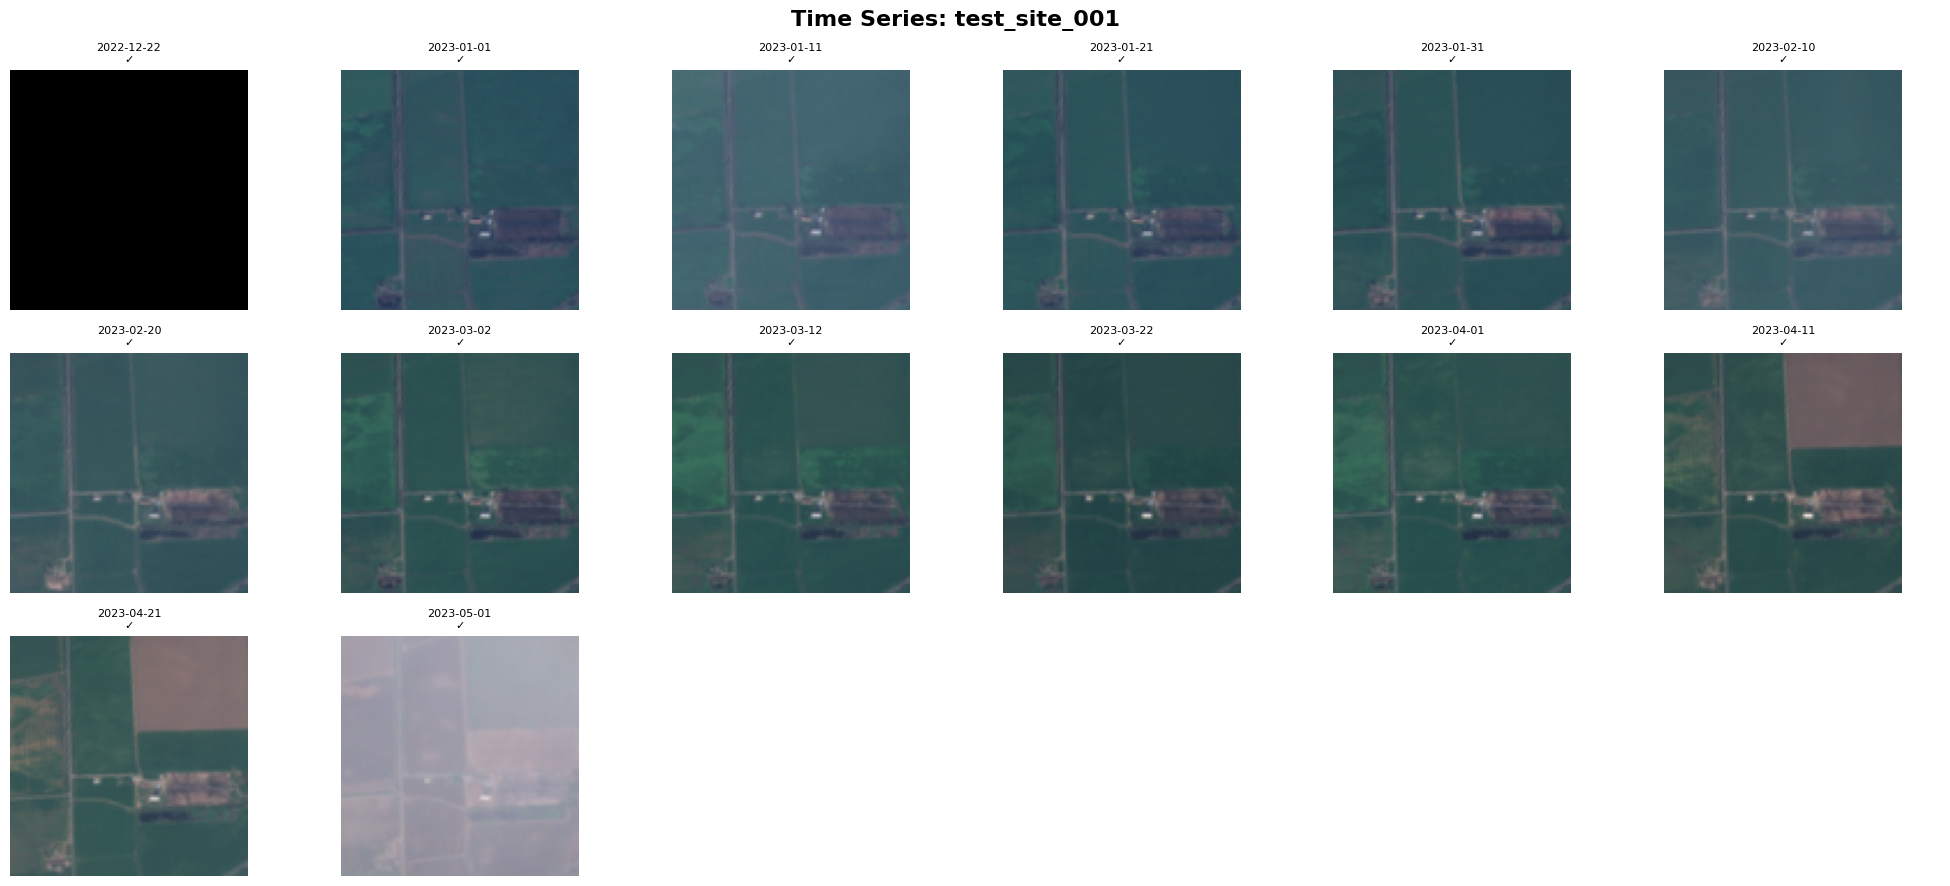


Calculating NDVI time series...


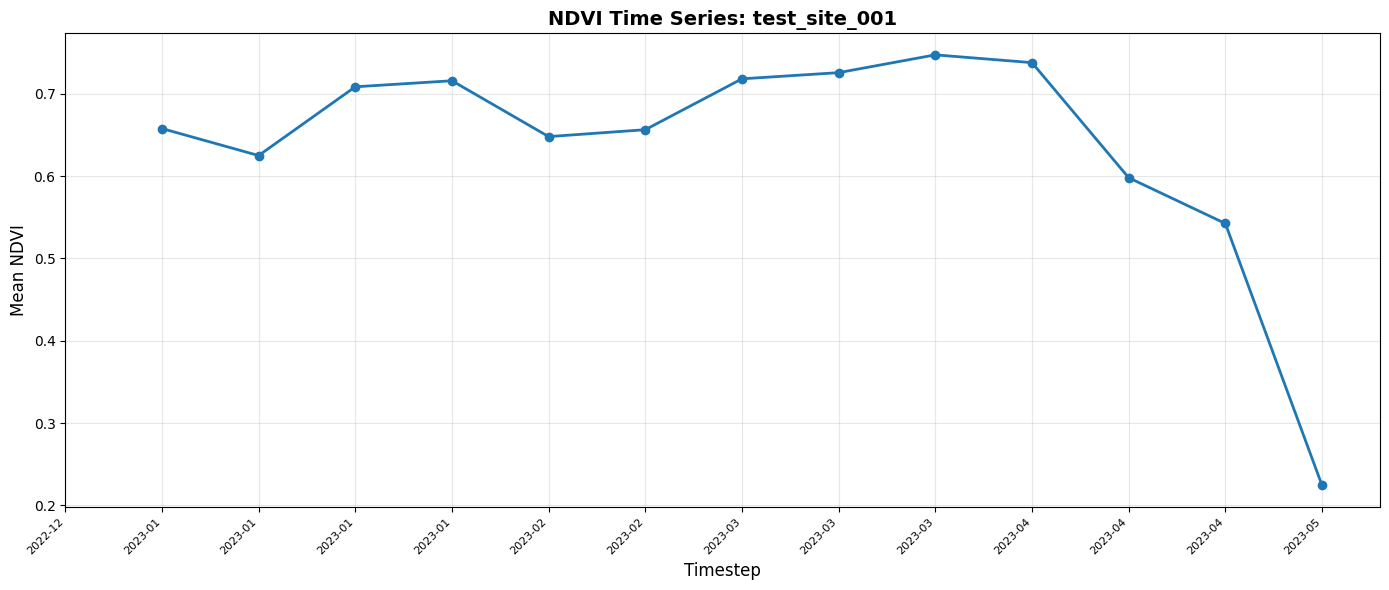


Generating data quality plot...


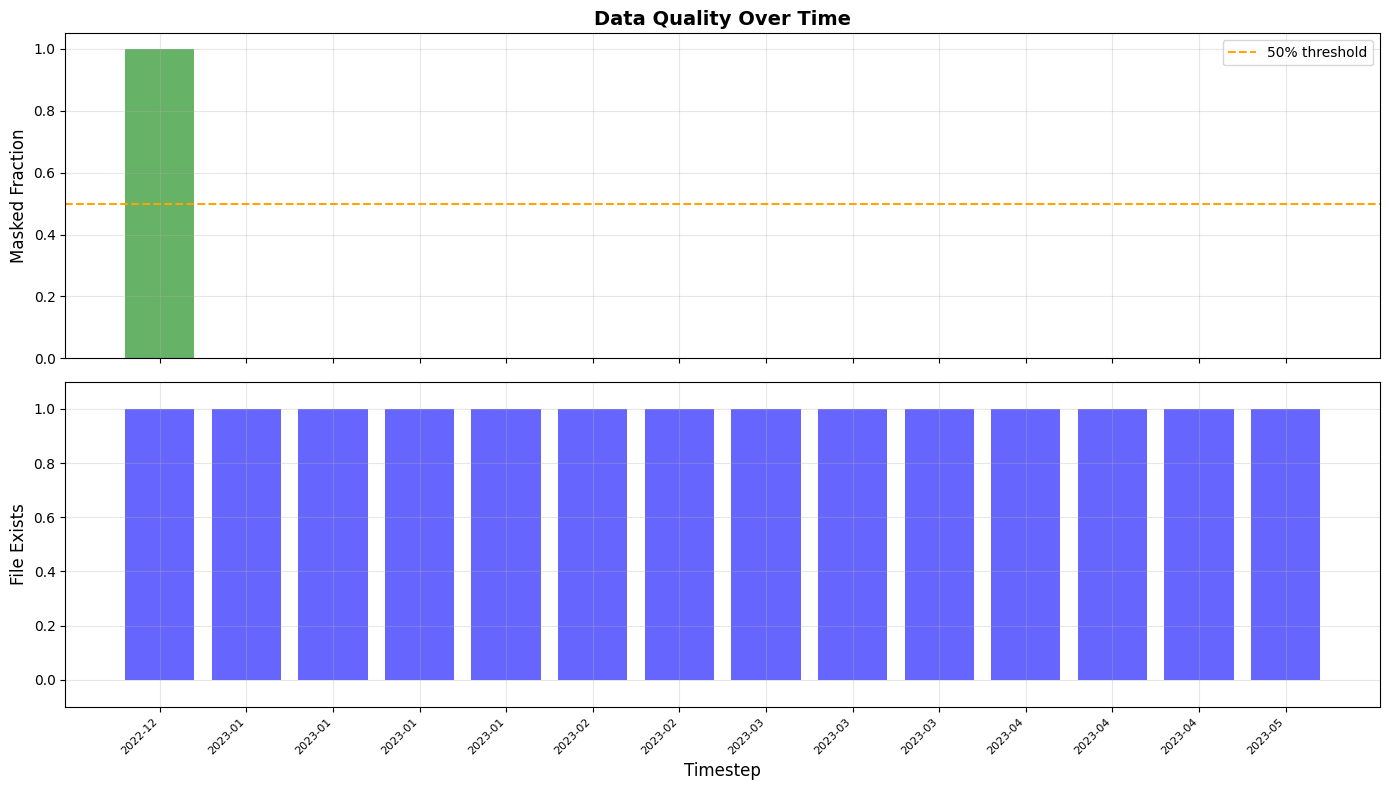


Generating detailed view of best timestep...


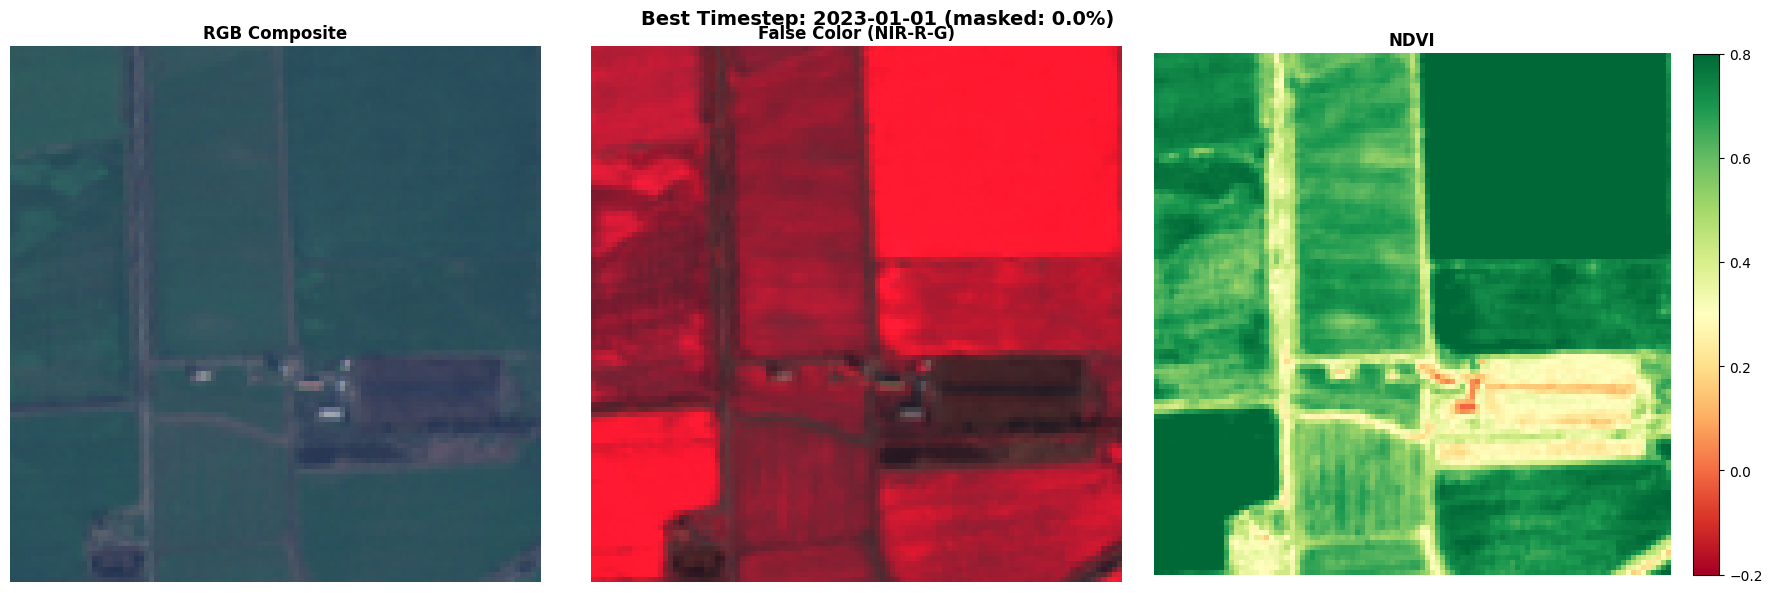


SUMMARY STATISTICS
Total timesteps: 14
Missing images: 0
Mean NDVI: 0.639
Mean masked fraction: 7.1%
Best timestep: 1 (2023-01-01)


In [16]:
site_id = "test_site_001"  # Change to your site ID
stack_file = f"./test_timeseries_output_L1C/{site_id}_stack.tif"
metadata_file = f"./test_timeseries_output_L1C/{site_id}_metadata.json"

visualize_timeseries_stack(stack_file, metadata_file)

In [17]:
# try it if it has missing images

# Test output directory
TEST_OUT_DIR = './test_timeseries_output_L1C_small_timestep'
os.makedirs(TEST_OUT_DIR, exist_ok=True)

print("="*70)
print("TEST 1: retrieve_time_series_stack()")
print("="*70)

# Test with a known good location
test_site_id = "test_site_001"
test_lat = 37.5
test_lon = -120.5
test_date = datetime(2023, 6, 15)

print(f"\nDownloading stack for:")
print(f"  Site ID: {test_site_id}")
print(f"  Location: ({test_lat}, {test_lon})")
print(f"  Date: {test_date}")
print(f"  Output: {TEST_OUT_DIR}\n")

try:
    retrieve_time_series_stack(
        site_id=test_site_id,
        lat=test_lat,
        lon=test_lon,
        date=test_date,
        collection="L1C",
        out_dir=TEST_OUT_DIR,
        start_month=1,
        num_windows=12,  # Use fewer windows for faster testing
        timestep=1,
        window_buffer=1
    )
    print("\n✓ retrieve_time_series_stack() completed successfully\n")
except Exception as e:
    print(f"\n✗ retrieve_time_series_stack() failed: {e}\n")
    import traceback
    traceback.print_exc()
    sys.exit(1)

TEST 1: retrieve_time_series_stack()

  Site ID: test_site_001
  Location: (37.5, -120.5)
  Date: 2023-06-15 00:00:00
  Output: ./test_timeseries_output_L1C_small_timestep




✓ retrieve_time_series_stack() completed successfully



Site: test_site_001
Location: (37.5, -120.5)
Shape: [14, 10, 104, 103]
Bands: ['B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'B11', 'B12']

Unstacked shape: (14, 10, 104, 103)
Nodata value: 0.0

Generating grid view of all timesteps...


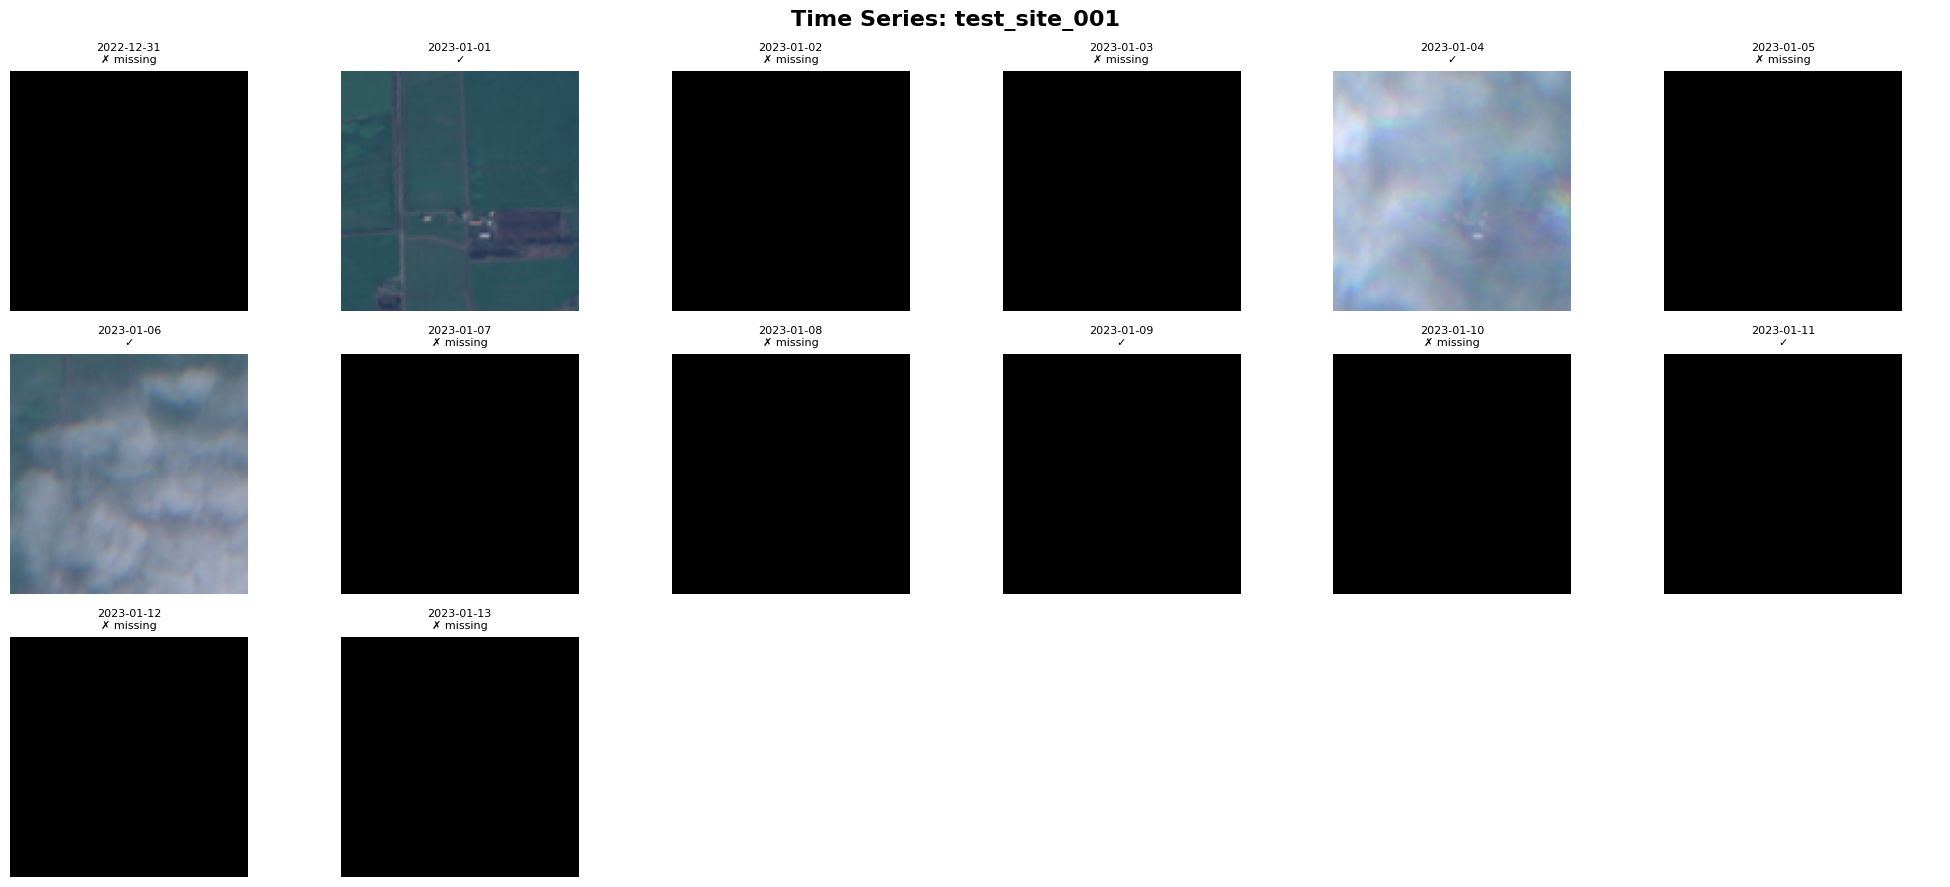


Calculating NDVI time series...


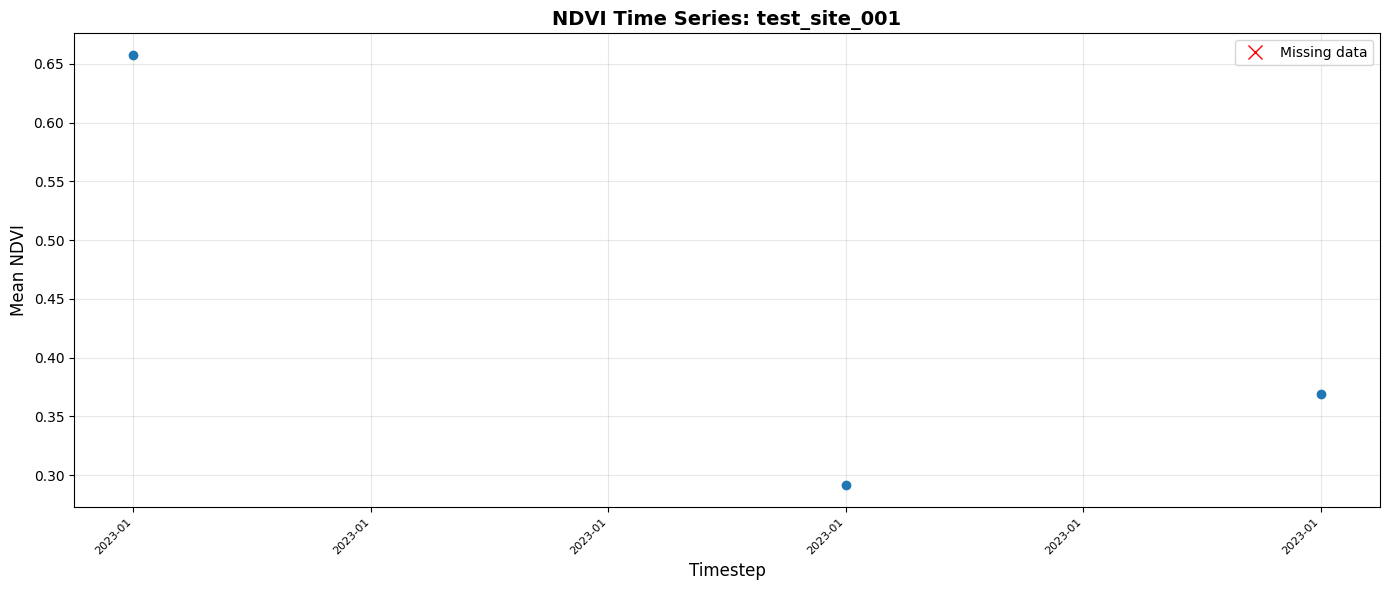


Generating data quality plot...


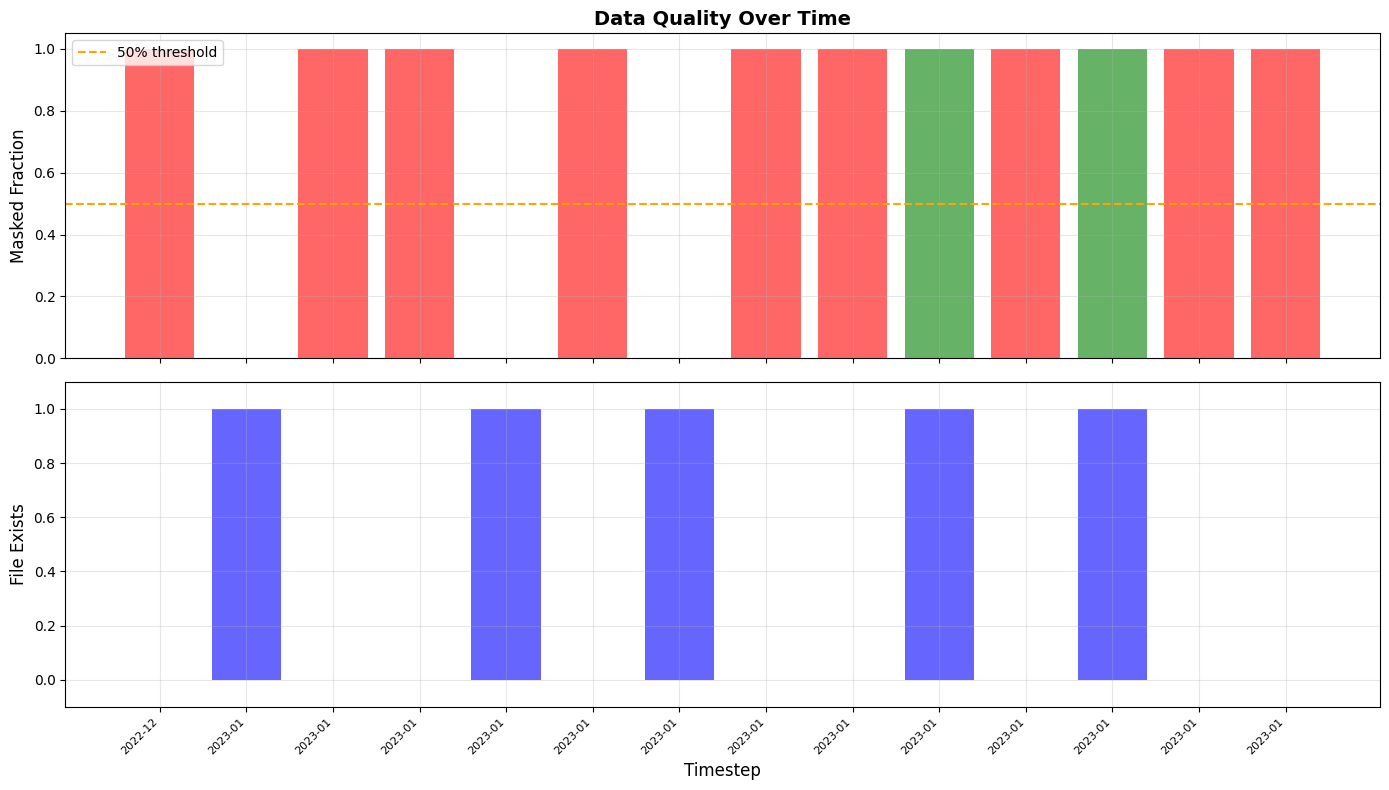


Generating detailed view of best timestep...


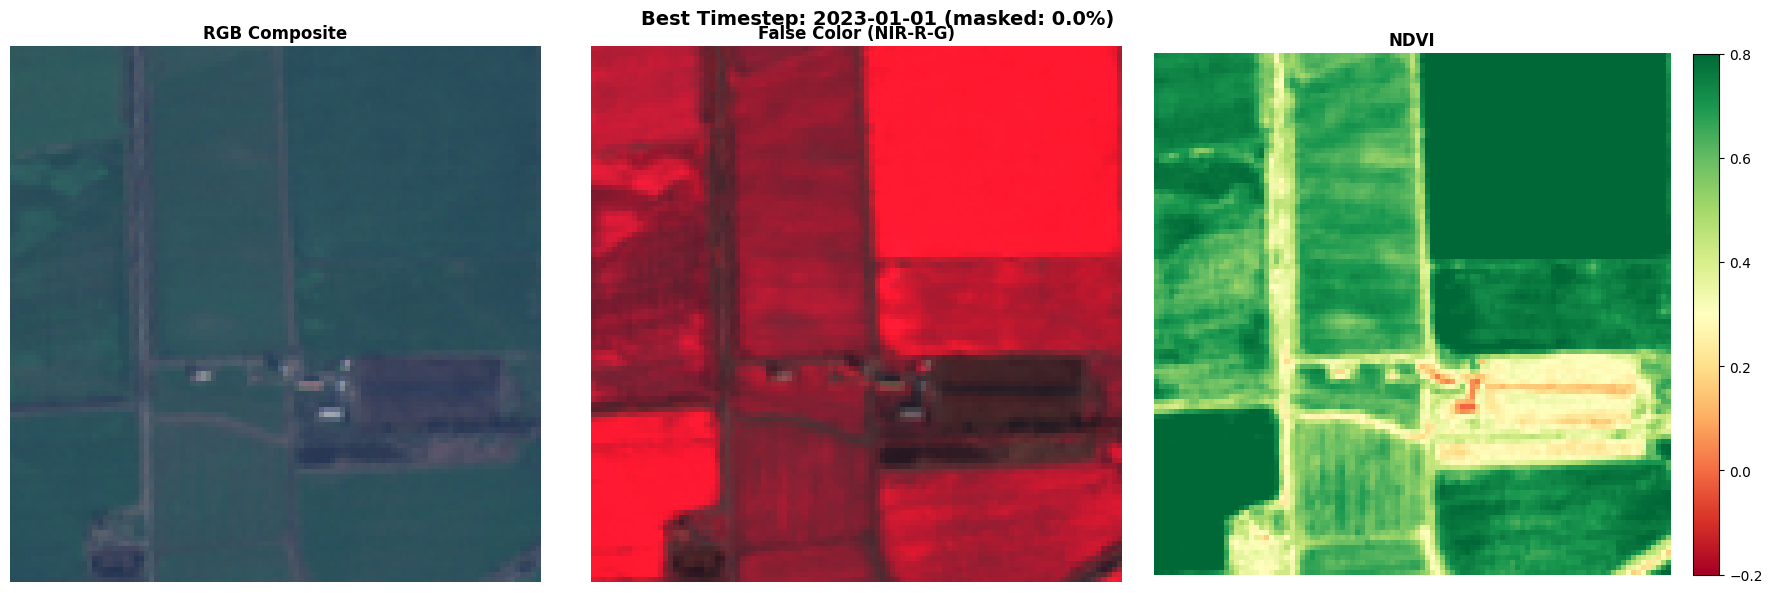


SUMMARY STATISTICS
Total timesteps: 14
Missing images: 9
Mean NDVI: 0.439
Mean masked fraction: 78.6%
Best timestep: 1 (2023-01-01)


In [18]:
site_id = "test_site_001"  # Change to your site ID
stack_file = f"./test_timeseries_output_L1C_small_timestep/{site_id}_stack.tif"
metadata_file = f"./test_timeseries_output_L1C_small_timestep/{site_id}_metadata.json"

visualize_timeseries_stack(stack_file, metadata_file)